Loading and preparing data...
Data preparation complete.

==================== Processing Look-back: 21 days ====================
Creating sequences with look-back = 21...
Train shape: (1360, 21, 7), Test shape: (340, 21, 7)
Training model...
Training complete.
Making predictions...
Saving scatter data to D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder\tempo.xlsx...
Successfully saved training and testing scatter data.
Generating scatter plots...


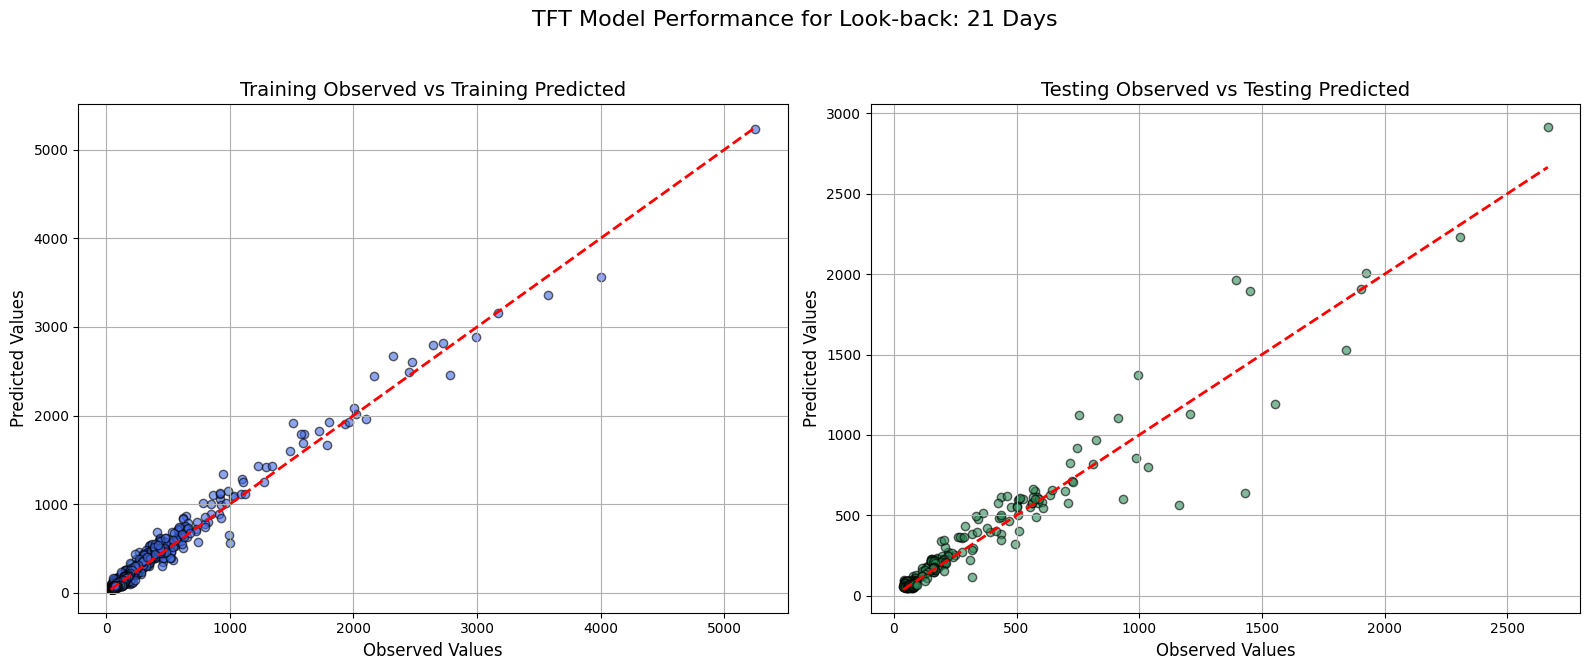

Model for look-back 21 saved to: D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder\final_model_lb21.keras


📋📋📋 Final Model Performance Metrics Across All Look-backs 📋📋📋
                        r      R2     NSE     RMSE      MAE   std_obs  \
Look-back Dataset                                                       
21        Train    0.9902  0.9759  0.9759  57.8108  34.5125  372.0519   
          Test     0.9645  0.9257  0.9257  94.0768  44.3981  345.1160   

                     std_pred  
Look-back Dataset              
21        Train    380.064209  
          Test     352.252686  

✅ Performance metrics successfully saved to:
   D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder\tft.xlsx


In [2]:
# =================================================================================
# Section 1: Imports and Setup
# =================================================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
import random
import os
import matplotlib.pyplot as plt

# =================================================================================
# Section 2: Configuration and Hyperparameters
# =================================================================================

# --- File and Directory Paths ---
# Path to save the final performance metrics Excel file
EXCEL_SAVE_PATH = r"D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder\tft.xlsx"
# Path to save the trained models
MODEL_SAVE_PATH = r"D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder"
# Path for the scatter plot data Excel file
SCATTER_EXCEL_PATH = r"D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\TFT\New folder\tempo.xlsx"

# --- Data and Feature Configuration ---
# List of features to be used from the CSV file
FEATURES_TO_USE = ['ET', 'WS', 'T_MAX', 'T_MIN', 'RH', 'R', 'Q']
# The target variable we want to predict
TARGET_VARIABLE = "Q"

# --- Model Hyperparameters ---
# The main dimension for embeddings and transformer layers
HIDDEN_DIM = 140
# Number of encoder blocks in the transformer
NUM_TRANSFORMER_BLOCKS = 3
# Number of attention heads in the MultiHeadAttention layer
NUM_ATTENTION_HEADS = 4
# Dimension of each attention head
KEY_DIM = 16
# Dropout rate within the MultiHeadAttention layer
ATTENTION_DROPOUT_RATE = 0.1
# Dropout rate for the MCDropout layers
MC_DROPOUT_RATE_1 = 0.1 # For layers inside the transformer block
MC_DROPOUT_RATE_2 = 0.2 # For the final dense layer block

# --- Training Hyperparameters ---
# A list of sequence lengths (look-back periods) to train and evaluate
LOOK_BACKS = [21]
# Maximum number of epochs for training
EPOCHS = 300
# Number of samples per gradient update
BATCH_SIZE = 16
# Learning rate for the AdamW optimizer
LEARNING_RATE = 0.0003
# Patience for the EarlyStopping callback (stops training if no improvement)
EARLY_STOPPING_PATIENCE = 15
# Number of Monte Carlo iterations for uncertainty prediction
N_ITER_TRAIN = 150
N_ITER_TEST = 200

# =================================================================================
# Section 3: Setup and Utility Functions
# =================================================================================

# Create the necessary directories if they don't exist
os.makedirs(os.path.dirname(SCATTER_EXCEL_PATH), exist_ok=True)

def set_seeds(seed=42):
    """Ensures that results are reproducible for consistent outcomes."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds()

# =================================================================================
# Section 4: Data Loading and Preprocessing
# =================================================================================

print("Loading and preparing data...")
try:
    df = pd.read_csv(r"D:\Projects\PROJECT 05 - FLOOD PREDICTION\New models\dataset\NEWSTATION.csv")
except FileNotFoundError:
    print("Error: 'NEWSTATION.csv' not found. Please ensure the file is in the correct directory.")
    exit()

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False, errors='coerce')
df = df.sort_values('Date')
df.rename(columns={'WindSpeed':'WS', 'TemperatureMaximum':'T_MAX', 'TemperatureMinimum':'T_MIN', 'RelativeHumidity':'RH', 'Rainfall':'R', 'EvaporTranspiration':'ET', 'Discharge':'Q'}, inplace=True)

# Scale the features using StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[FEATURES_TO_USE]), columns=[f"{col}_scaled" for col in FEATURES_TO_USE])
df = pd.concat([df, df_scaled], axis=1)
print("Data preparation complete.")

def create_multivariate_sequences(data, target_column_index, look_back):
    """Converts time series data into input sequences (X) and target values (y)."""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back, :])
        y.append(data[i+look_back, target_column_index])
    return np.array(X), np.array(y)

# =================================================================================
# Section 5: Custom Keras Layers
# =================================================================================

class PositionalEncoding(layers.Layer):
    """Custom layer to inject positional information into the input sequences."""
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = tf.shape(x)[2]
        pos = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
        i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates
        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        if d_model % 2 != 0:
            cosines = tf.pad(cosines, [[0, 0], [0, 1]])
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = tf.expand_dims(pos_encoding, axis=0)
        return x + pos_encoding

class MCDropout(tf.keras.layers.Dropout):
    """Custom Monte Carlo Dropout layer that remains active during inference."""
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

# =================================================================================
# Section 6: Temporal Fusion Transformer (TFT) Model Definition
# =================================================================================

def tft_model(input_shape):
    """
    Defines the architecture for the Temporal Fusion Transformer model.
    This model consists of:
    1. A Variable Selection Network to learn feature importance.
    2. Positional Encoding to retain sequence order.
    3. A stack of Transformer Encoder blocks for temporal processing.
    4. A final dense network to produce the output prediction.
    """
    inputs = layers.Input(shape=input_shape)

    # --- 1. Variable Selection & Embedding ---
    # A TimeDistributed Dense layer processes each time step independently.
    # This layer has HIDDEN_DIM (140) nodes and acts as an initial feature embedding.
    var_selection = layers.TimeDistributed(layers.Dense(HIDDEN_DIM, activation='gelu'))(inputs)
    x = PositionalEncoding()(var_selection)

    # --- 2. Transformer Encoder Blocks ---
    # The core of the model, consisting of a stack of transformer blocks.
    # Number of blocks is controlled by NUM_TRANSFORMER_BLOCKS (3).
    for _ in range(NUM_TRANSFORMER_BLOCKS):
        # --- Multi-Head Self-Attention ---
        attn_input = x
        # Each attention layer has NUM_ATTENTION_HEADS (4) and a KEY_DIM (16) per head.
        attn_output = layers.MultiHeadAttention(
            num_heads=NUM_ATTENTION_HEADS,
            key_dim=KEY_DIM,
            dropout=ATTENTION_DROPOUT_RATE
        )(attn_input, attn_input)
        attn_output = MCDropout(MC_DROPOUT_RATE_1)(attn_output)
        x = layers.Add()([attn_input, attn_output]) # Residual connection
        x = layers.LayerNormalization(epsilon=1e-6)(x)

        # --- Gated Residual Network (GRN) ---
        grn_input = x
        # First dense layer in GRN has HIDDEN_DIM / 2 (70) nodes.
        grn_dense = layers.Dense(HIDDEN_DIM // 2, activation='gelu')(grn_input)
        # Second dense layer projects back to HIDDEN_DIM (140) nodes.
        grn_dense = layers.Dense(x.shape[-1])(grn_dense)
        grn_dense = MCDropout(MC_DROPOUT_RATE_1)(grn_dense)
        # Gating layer to control information flow.
        gate = layers.Activation('gelu')(layers.Dense(x.shape[-1])(grn_input))
        grn_output = layers.Multiply()([grn_dense, gate])
        x = layers.Add()([grn_input, grn_output]) # Residual connection
        x = layers.LayerNormalization(epsilon=1e-6)(x)

    # --- 3. Output Layer ---
    # Selects the output from the very last time step of the sequence.
    x = layers.Lambda(lambda t: t[:, -1, :])(x)
    # A final dense block for prediction.
    # First dense layer has HIDDEN_DIM / 2 (70) nodes.
    x = layers.Dense(HIDDEN_DIM // 2, activation='gelu')(x)
    x = MCDropout(MC_DROPOUT_RATE_2)(x)
    # Final output layer has 1 node for the regression task (predicting discharge).
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE),
                  loss='mse', metrics=['mae'])
    return model

# =================================================================================
# Section 7: Prediction and Evaluation Functions
# =================================================================================

def predict_with_uncertainty(f_model, X, n_iter):
    """Performs multiple forward passes with dropout active to estimate uncertainty."""
    preds = np.array([f_model(X, training=True).numpy().flatten() for _ in range(n_iter)])
    mean_pred = preds.mean(axis=0)
    std_pred = preds.std(axis=0)
    return mean_pred, std_pred

def calculate_nse(y_true, y_pred):
    """Calculates the Nash-Sutcliffe Efficiency metric."""
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (numerator / denominator)

def get_metrics(y_true, y_pred):
    """Calculates and returns a dictionary of key performance metrics."""
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "r": r, "R2": r2_score(y_true, y_pred), "NSE": calculate_nse(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)), "MAE": mean_absolute_error(y_true, y_pred),
        "std_obs": np.std(y_true), "std_pred": np.std(y_pred)
    }

# =================================================================================
# Section 8: Main Training and Evaluation Loop
# =================================================================================

all_results = []
scaled_features = df[[f"{col}_scaled" for col in FEATURES_TO_USE]].values
target_column_index = FEATURES_TO_USE.index(TARGET_VARIABLE)

for look_back in LOOK_BACKS:
    print(f"\n{'='*20} Processing Look-back: {look_back} days {'='*20}")

    # --- Data Preparation for the current look-back ---
    print(f"Creating sequences with look-back = {look_back}...")
    X, y = create_multivariate_sequences(scaled_features, target_column_index, look_back)
    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # --- Model Training ---
    set_seeds()
    model = tft_model(X_train.shape[1:])
    best_model_filepath = os.path.join(MODEL_SAVE_PATH, f"best_model_lb{look_back}.keras")
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(best_model_filepath, save_best_only=True, monitor='val_loss'),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=0)
    ]
    print("Training model...")
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=0)
    print("Training complete.")

    # --- Prediction and Evaluation ---
    print("Making predictions...")
    y_test_pred_mc, _ = predict_with_uncertainty(model, X_test, n_iter=N_ITER_TEST)
    y_train_pred_mc, _ = predict_with_uncertainty(model, X_train, n_iter=N_ITER_TRAIN)

    q_scaler = StandardScaler()
    q_scaler.mean_ = scaler.mean_[target_column_index:target_column_index+1]
    q_scaler.scale_ = scaler.scale_[target_column_index:target_column_index+1]
    y_test_orig = q_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_test_pred_mc_orig = q_scaler.inverse_transform(y_test_pred_mc.reshape(-1, 1)).flatten()
    y_train_orig = q_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
    y_train_pred_mc_orig = q_scaler.inverse_transform(y_train_pred_mc.reshape(-1, 1)).flatten()

    train_metrics = get_metrics(y_train_orig, y_train_pred_mc_orig)
    train_metrics.update({'Look-back': look_back, 'Dataset': 'Train'})
    test_metrics = get_metrics(y_test_orig, y_test_pred_mc_orig)
    test_metrics.update({'Look-back': look_back, 'Dataset': 'Test'})
    all_results.extend([train_metrics, test_metrics])

    # --- Save Scatter Data and Plot Results ---
    print(f"Saving scatter data to {SCATTER_EXCEL_PATH}...") ### <-- MODIFIED
    try:
        # Create separate dataframes for training and testing data ### <-- MODIFIED
        train_scatter_df = pd.DataFrame({ ### <-- MODIFIED
            'Training Observed': y_train_orig, ### <-- MODIFIED
            'Training Predicted': y_train_pred_mc_orig ### <-- MODIFIED
        }) ### <-- MODIFIED
        test_scatter_df = pd.DataFrame({ ### <-- MODIFIED
            'Testing Observed': y_test_orig, ### <-- MODIFIED
            'Testing Predicted': y_test_pred_mc_orig ### <-- MODIFIED
        }) ### <-- MODIFIED
        
        # Concatenate them side-by-side; pandas will handle unequal lengths by filling with NaN ### <-- MODIFIED
        scatter_df = pd.concat([train_scatter_df, test_scatter_df], axis=1) ### <-- MODIFIED
        
        scatter_df.to_excel(SCATTER_EXCEL_PATH, index=False) ### <-- MODIFIED
        print("Successfully saved training and testing scatter data.") ### <-- MODIFIED
    except Exception as e:
        print(f"Error saving scatter data to Excel: {e}") ### <-- MODIFIED


    print("Generating scatter plots...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"TFT Model Performance for Look-back: {look_back} Days", fontsize=16)
    ax1.scatter(y_train_orig, y_train_pred_mc_orig, alpha=0.6, edgecolors='k', c='royalblue')
    ax1.plot([y_train_orig.min(), y_train_orig.max()], [y_train_orig.min(), y_train_orig.max()], 'r--', lw=2)
    ax1.set_title("Training Observed vs Training Predicted", fontsize=14)
    ax1.set_xlabel("Observed Values", fontsize=12); ax1.set_ylabel("Predicted Values", fontsize=12); ax1.grid(True)
    ax2.scatter(y_test_orig, y_test_pred_mc_orig, alpha=0.6, edgecolors='k', c='seagreen')
    ax2.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
    ax2.set_title("Testing Observed vs Testing Predicted", fontsize=14)
    ax2.set_xlabel("Observed Values", fontsize=12); ax2.set_ylabel("Predicted Values", fontsize=12); ax2.grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

    # --- Save Final Model ---
    final_model_filepath = os.path.join(MODEL_SAVE_PATH, f"final_model_lb{look_back}.keras")
    model.save(final_model_filepath)
    print(f"Model for look-back {look_back} saved to: {final_model_filepath}")

# =================================================================================
# Section 9: Final Results Summary
# =================================================================================

print("\n\n📋📋📋 Final Model Performance Metrics Across All Look-backs 📋📋📋")
results_df = pd.DataFrame(all_results).set_index(['Look-back', 'Dataset'])
results_df = results_df[['r', 'R2', 'NSE', 'RMSE', 'MAE', 'std_obs', 'std_pred']]
print(results_df.round(4))

try:
    results_df.to_excel(EXCEL_SAVE_PATH)
    print(f"\n✅ Performance metrics successfully saved to:\n   {EXCEL_SAVE_PATH}")
except Exception as e:
    print(f"\n❌ Error saving performance metrics to Excel file: {e}")